# Analyse Exploratoire des Données — Churn Bancaire

**Objectif** : explorer le jeu de données brut `data_churn.txt` (informations clients, comptes
et produits bancaires) afin de comprendre sa structure, sa qualité et les facteurs associés au
churn (fermeture de compte), avant la phase d'ETL.

**Périmètre de ce notebook** : ce notebook travaille uniquement sur le **fichier principal brut**.
Les jointures avec les 8 tables de dimensions (`dim_*.xlsx`) et l'agrégation au niveau client sont
traitées dans le pipeline ETL (`01_etl/`), pas ici — voir le README du dossier ETL.

**Définition du churn retenue dans ce notebook** (conforme à la documentation) :

```
churn = 1  si  ACCOUNT_STATUS == "Closed"
churn = 0  si  ACCOUNT_STATUS == "Active"
```

Cette définition est calculée à la **granularité de la ligne** (couple client–compte), pas au
niveau client. Un même client peut donc contribuer plusieurs lignes, actives et/ou closes. C'est
la définition de référence de la documentation ; une définition plus fine au niveau client
pourra être proposée et justifiée séparément lors de l'étape ETL/modélisation si l'équipe le
décide.

---

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(suppress=True)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Année de référence pour les calculs d'âge / d'ancienneté.
# Centralisée ici : à mettre à jour si le notebook est ré-exécuté plus tard,
# ou à remplacer par `pd.Timestamp.today().year` pour un calcul toujours à jour.
REFERENCE_YEAR = 2026

## 2. Chargement des données

Le fichier est chargé tel quel, sans conversion de type a priori : on observe d'abord les types
inférés par pandas avant de décider des conversions nécessaires (notamment les dates, stockées en
`YYYYMMDD` numérique d'après la documentation).

In [2]:
df = pd.read_csv("../../data/data_churn.txt", sep=",")

print(f"Nombre de lignes   : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.head()

Nombre de lignes   : 528,883
Nombre de colonnes : 34


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.00,1290627.00,10954600.00,4.50,CURRENT,Retail,4
1,C318648,A0373555,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,...,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,20260102.00,NaN,NaN,NaN,UNAUTH,Retail,4
2,C318650,A0348290,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.548,Crédit rénovation,1251227.00,1380527.00,113593077.00,4.50,CURRENT,Retail,4
3,C318650,A0257995,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,ACCOUNTS,BANK.CUR.ACCT.ALL.TOURS.CARTE,Compte Allocation Touristique TND,NaN,NaN,0.00,NaN,NaN,Retail,4
4,C318648,A0312991,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,...,NaN,NaN,DEPOTS A TERME,NaN,NaN,NaN,NaN,NaN,Retail,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528883 entries, 0 to 528882
Data columns (total 34 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CUSTOMER_NO        528883 non-null  str    
 1   ACCOUNT_NO         484443 non-null  str    
 2   NATIONALITY        528883 non-null  str    
 3   RESIDENCE          528883 non-null  str    
 4   MARITAL_STATUS     410185 non-null  str    
 5   CUST_OPENING_DATE  515261 non-null  float64
 6   DATE_OF_BIRTH      427568 non-null  float64
 7   NATURE_CLIENT      528805 non-null  str    
 8   BRANCH             528883 non-null  str    
 9   SCORE_KYC          528038 non-null  str    
 10  COMPLETED_FILE     289239 non-null  str    
 11  LAST_REVIEW_DATE   501478 non-null  float64
 12  NEXT__REVIEW_DATE  504301 non-null  float64
 13  ACCOUNT_STATUS     484443 non-null  str    
 14  ACCT_OPENING_DATE  383958 non-null  float64
 15  ACCOUNT_CATEGORY   383958 non-null  float64
 16  ACCOUNT_TYPE_

## 3. Aperçu des données et types

### 3.1 Statistiques descriptives

In [4]:
# Statistiques descriptives pour les colonnes numériques
df.describe()

,CUST_OPENING_DATE,DATE_OF_BIRTH,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCT_CLOSE_DATE,ACCT_BALANCE,INDUSTRY,SALARY,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,LOB
count,515261.00,427568.00,501478.00,504301.00,383958.00,383958.00,221941.00,383958.00,528883.00,202234.00,92727.00,79550.00,305363.00,79548.00,528883.00
mean,20136149.53,1976.25,20221483.27,20255637.90,20191930.61,4999.71,20241817.93,4409.02,7983.97,5588.48,6270502.37,3980789.49,41297692.49,8.65,6.06
std,68027.23,17.29,35431.95,34841.38,78138.15,2170.51,13875.96,810619.54,2511.47,149836.63,8375981.70,6629581.69,442802606.00,2.49,5.46
min,19960122.00,1190.00,20040930.00,20060930.00,19800101.00,1001.00,20220412.00,-43823115.66,111.00,0.00,1131130.00,-19000000.00,-43823115.66,0.00,1.00
25%,20070824.00,1964.00,20200923.00,20240610.00,20151209.00,3045.00,20230410.00,0.00,9000.00,400.00,1251225.00,1260318.00,7.08,8.33,4.00
50%,20140925.00,1977.00,20230323.00,20261017.00,20220720.00,6001.00,20241108.00,2.09,9000.00,612.00,1251231.00,1261205.00,1510.60,9.33,4.00
75%,20191108.00,1989.00,20250508.00,20280217.00,20251029.00,6001.00,20251205.00,1087.91,9000.00,1647.00,20250530.00,1341031.00,149000.00,10.08,4.00
max,20260219.00,2026.00,20260219.00,20301230.00,20260219.00,9005.00,20260219.00,64141930.15,9998.00,25000000.00,20261226.00,20310123.00,31714285714.00,13.33,999.00


In [5]:
# Statistiques pour les colonnes catégorielles / texte
df.describe(include=['object']).T

,count,unique,top,freq
CUSTOMER_NO,528883,363569,C155581,8091
ACCOUNT_NO,484443,410587,A0164634,93
NATIONALITY,528883,141,TN,509824
RESIDENCE,528883,137,TN,494836
MARITAL_STATUS,410185,4,M,219232
NATURE_CLIENT,528805,9,PPH,374968
BRANCH,528883,142,BR114,26573
SCORE_KYC,528038,5,LR,342717
COMPLETED_FILE,289239,1,YES,289239
ACCOUNT_STATUS,484443,2,Active,262502


### 3.2 Granularité du fichier

D'après la documentation, chaque ligne correspond à un couple **(client, compte produit)** :
un même client peut donc apparaître plusieurs fois s'il possède plusieurs comptes/produits. On
vérifie ce point directement sur les données avant d'aller plus loin, car cela conditionne
l'interprétation de toutes les statistiques qui suivent (un taux calculé "par ligne" n'est pas un
taux "par client").

Lignes                         : 528,883
Clients uniques (CUSTOMER_NO)  : 363,569
Comptes uniques (ACCOUNT_NO)   : 410,587
Lignes par client (moyenne)    : 1.45



Client avec le plus de lignes : C155581 (8091 lignes)
Part des clients avec une seule ligne : 87.1%


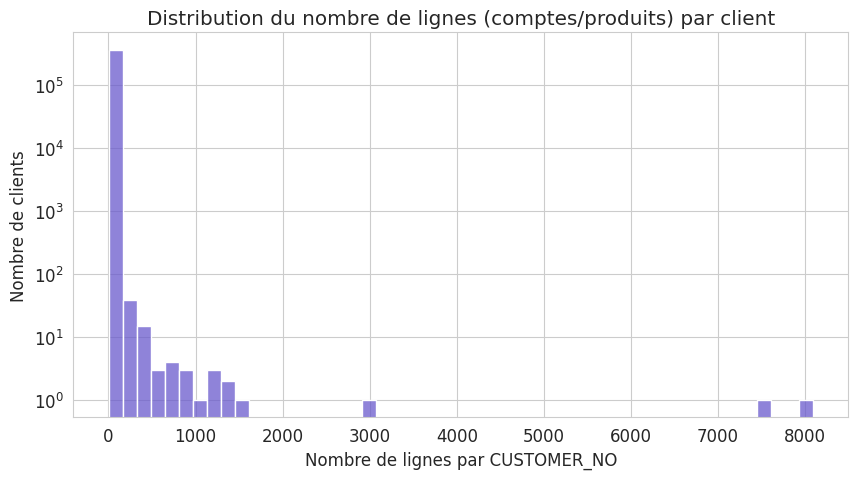

In [6]:
n_rows = len(df)
n_customers = df['CUSTOMER_NO'].nunique()
n_accounts = df['ACCOUNT_NO'].nunique(dropna=True)

print(f"Lignes                         : {n_rows:,}")
print(f"Clients uniques (CUSTOMER_NO)  : {n_customers:,}")
print(f"Comptes uniques (ACCOUNT_NO)   : {n_accounts:,}")
print(f"Lignes par client (moyenne)    : {n_rows / n_customers:.2f}")

rows_per_customer = df['CUSTOMER_NO'].value_counts()
print(f"\nClient avec le plus de lignes : {rows_per_customer.index[0]} "
      f"({rows_per_customer.iloc[0]} lignes)")
print(f"Part des clients avec une seule ligne : "
      f"{(rows_per_customer == 1).mean() * 100:.1f}%")

plt.figure(figsize=(10, 5))
sns.histplot(rows_per_customer, bins=50, color='slateblue')
plt.title("Distribution du nombre de lignes (comptes/produits) par client")
plt.xlabel("Nombre de lignes par CUSTOMER_NO")
plt.ylabel("Nombre de clients")
plt.yscale('log')
plt.show()

**Constat mesuré** : 87,1% des clients n'ont qu'une seule ligne, mais quelques clients (comptes
professionnels ou techniques) en concentrent un très grand nombre (jusqu'à plusieurs milliers) —
cette asymétrie est la raison pour laquelle toute statistique de churn calculée *par ligne* dans ce
notebook décrit le **portefeuille de comptes**, pas le **comportement client** moyen. Les deux
lectures sont légitimes mais répondent à des questions différentes ; ce notebook reste au niveau
ligne par cohérence avec la définition du churn de la documentation (`2_description_donnees.md`),
et documente ce choix explicitement ici plutôt que de le laisser implicite.

## 4. Conversion des dates

La documentation signale explicitement des **dates au format `YYYYMMDD` numérique à
convertir**. On centralise cette conversion dans une fonction unique, réutilisée pour toutes les
colonnes de date, plutôt que de répéter du slicing de chaînes de caractères au cas par cas (source
d'erreurs silencieuses si une colonne a un format légèrement différent).

⚠️ **Point de vigilance documenté, non résolu ici** : les colonnes `STARTDATE` et `MATURITYDATE`
contiennent un mélange de formats — certaines valeurs ressemblent à du `YYYYMMDD` à 8 chiffres
(ex. `20251002.0`), d'autres à un format à 7 chiffres différent (ex. `1251227.0`), et `MATURITYDATE`
contient au moins une valeur négative. Convertir ces deux colonnes nécessite de comprendre cet
encodage (probablement spécifique au système source) — **à clarifier avec l'équipe / l'encadrant
avant de les exploiter en ETL**. Ce notebook les laisse donc en l'état (non converties) et se
limite aux colonnes de date dont le format `YYYYMMDD` est cohérent.

### Note de méthode : pourquoi `df` n'est pas modifié dans cette section

Ici, on calcule un diagnostic (combien de dates se convertissent correctement) mais on ne
l'ajoute **pas** à `df`. La raison : ce sont des colonnes *jetables*, utiles une seule fois pour
ce contrôle qualité, pas pour le reste du notebook. Si on les ajoutait à `df`, le nombre de
colonnes de `df` passerait de 34 à 39 — et la section 5 (« valeurs manquantes ») compterait alors
ces colonnes ajoutées comme si elles faisaient partie du fichier source, ce qui rendrait le
rapport de complétude trompeur (« 32/39 colonnes ont des valeurs manquantes » au lieu de
« X/34 »). On garde donc le résultat dans une variable Python ordinaire (`parsed_dates`, un
dictionnaire), complètement séparée de `df`.

En revanche, plus loin dans ce notebook, deux colonnes *sont* ajoutées à `df` (`AGE` en section 8.1
et `SALARY_MISSING` en section 5.3) — celles-ci sont volontairement conservées car elles sont
réutilisées dans plusieurs analyses ultérieures (boxplots, comparaisons par statut). La règle
simple : une colonne dérivée qui sert plusieurs fois peut rejoindre `df` ; un calcul de diagnostic
ponctuel reste local.

In [7]:
def parse_yyyymmdd(series):
    """Convertit une colonne de dates stockées en float/str au format YYYYMMDD
    en datetime64. Les valeurs non convertibles (mauvais format, hors plage) deviennent
    NaT plutôt que de lever une erreur, afin de pouvoir les quantifier ensuite.
    Les valeurs déjà manquantes (NaN) restent NaT sans être comptées comme des échecs.
    """
    as_str = series.dropna().astype('int64').astype(str)
    parsed = pd.to_datetime(as_str, format='%Y%m%d', errors='coerce')
    return parsed.reindex(series.index)


date_cols_yyyymmdd = [
    'CUST_OPENING_DATE', 'LAST_REVIEW_DATE', 'NEXT__REVIEW_DATE',
    'ACCT_OPENING_DATE', 'ACCT_CLOSE_DATE',
]

# Important : les colonnes converties ('_DT') sont stockées dans un dictionnaire local
# `parsed_dates`, PAS dans `df`. On ne modifie pas `df` ici : il reste rigoureusement
# identique au fichier source (34 colonnes) pour toute la suite du notebook. Si l'on
# veut réutiliser une version datetime plus tard (section 11), on la recalcule à la
# volée à partir de `df` sans jamais lui ajouter de colonne de façon permanente.
parsed_dates = {}

print(f"{'Colonne':22s} | {'Valeurs renseignées':>20s} | {'Converties OK':>14s} | "
      f"{'Malformées (à investiguer)':>27s}")
for col in date_cols_yyyymmdd:
    parsed = parse_yyyymmdd(df[col])
    parsed_dates[col] = parsed
    n_present = df[col].notna().sum()
    n_converted = parsed.notna().sum()
    n_malformed = n_present - n_converted  # renseigné mais non convertible -> vrai problème
    print(f"{col:22s} | {n_present:20,d} | {n_converted:14,d} | {n_malformed:27,d}")

Colonne                |  Valeurs renseignées |  Converties OK |  Malformées (à investiguer)


CUST_OPENING_DATE      |              515,261 |        515,261 |                           0


LAST_REVIEW_DATE       |              501,478 |        501,478 |                           0


NEXT__REVIEW_DATE      |              504,301 |        504,301 |                           0
ACCT_OPENING_DATE      |              383,958 |        383,958 |                           0


ACCT_CLOSE_DATE        |              221,941 |        221,941 |                           0


## 5. Analyse des valeurs manquantes

### 5.1 Valeurs manquantes par colonne

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Pct', ascending=False)

print(f"Colonnes avec au moins une valeur manquante : {len(missing_df)} / {df.shape[1]}")
missing_df

Colonnes avec au moins une valeur manquante : 27 / 34


,Missing,Pct
MATURITYDATE,449333,84.96
FIXEDRATE,449335,84.96
PRODUCT_STATUS,436160,82.47
STARTDATE,436156,82.47
CLOSURE_REASON,385328,72.86
SALARY,326649,61.76
ACCT_CLOSE_DATE,306942,58.04
COMPLETED_FILE,239644,45.31
AMOUNT,223520,42.26
PRODUCT_LINE,208846,39.49


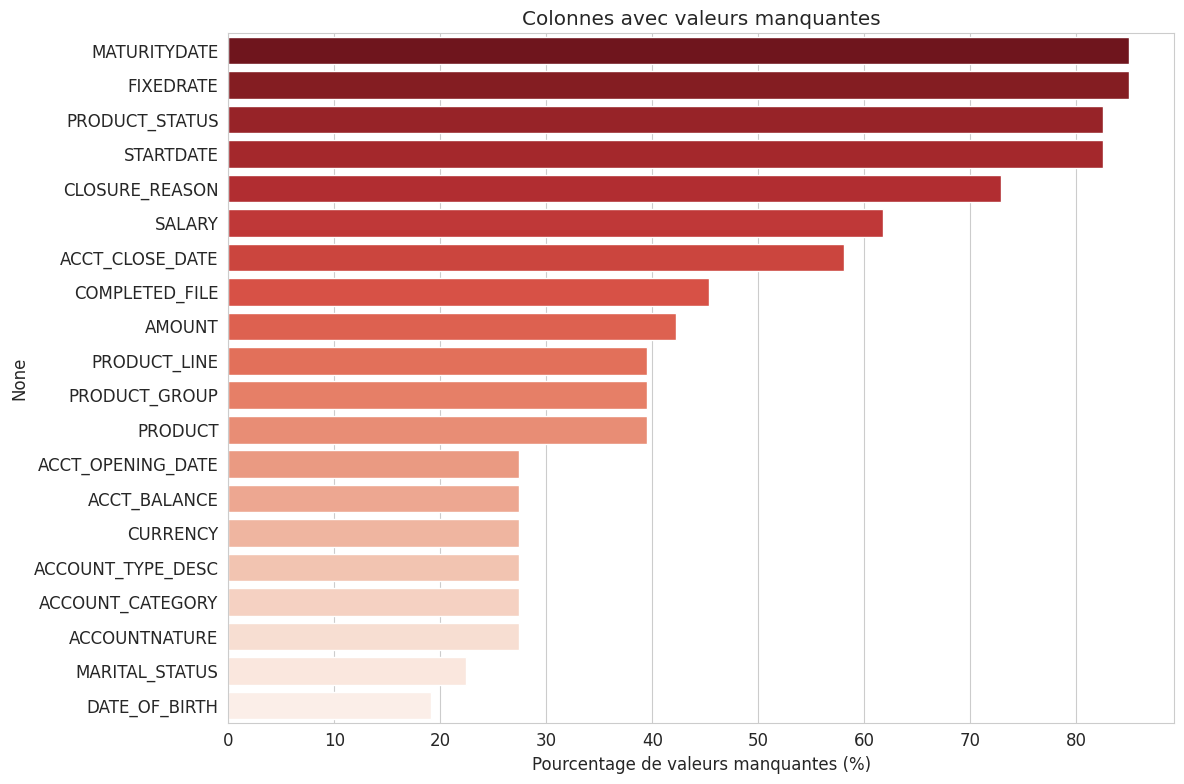

In [9]:
plt.figure(figsize=(12, 8))
top_missing = missing_df.head(20)
sns.barplot(x=top_missing['Pct'], y=top_missing.index, palette='Reds_r')
plt.xlabel('Pourcentage de valeurs manquantes (%)')
plt.title('Colonnes avec valeurs manquantes')
plt.tight_layout()
plt.show()

### 5.2 Nullité structurelle vs. nullité aléatoire

Plusieurs colonnes produit (`PRODUCT_GROUP`, `PRODUCT_LINE`, `PRODUCT`, `ACCOUNTNATURE`) ont des
taux de valeurs manquantes très proches. On vérifie ici si elles sont manquantes **ensemble** sur
les mêmes lignes — ce qui indiquerait une nullité *structurelle* (la ligne ne correspond simplement
pas à un produit avec ces attributs) plutôt qu'un problème de saisie aléatoire. La distinction
importe pour l'ETL : on n'impute pas une nullité structurelle de la même façon qu'une donnée
manquante par erreur.

In [10]:
product_cols = ['PRODUCT_GROUP', 'PRODUCT_LINE', 'PRODUCT', 'ACCOUNTNATURE']
product_cols = [c for c in product_cols if c in df.columns]

null_pattern = df[product_cols].isnull()
# Pour chaque ligne, est-ce que TOUTES ces colonnes sont nulles, ou AUCUNE, ou un mélange ?
all_null = null_pattern.all(axis=1).sum()
none_null = (~null_pattern.any(axis=1)).sum()
mixed = len(df) - all_null - none_null

print(f"Lignes où les {len(product_cols)} colonnes produit sont TOUTES nulles : {all_null:,} "
      f"({all_null/len(df)*100:.1f}%)")
print(f"Lignes où AUCUNE n'est nulle                                   : {none_null:,} "
      f"({none_null/len(df)*100:.1f}%)")
print(f"Lignes avec un mélange (certaines nulles, d'autres non)        : {mixed:,} "
      f"({mixed/len(df)*100:.1f}%)")

Lignes où les 4 colonnes produit sont TOUTES nulles : 144,925 (27.4%)
Lignes où AUCUNE n'est nulle                                   : 320,037 (60.5%)
Lignes avec un mélange (certaines nulles, d'autres non)        : 63,921 (12.1%)


**Constat mesuré** : 27,4% des lignes ont les 4 colonnes produit toutes vides, 60,5% les ont
toutes renseignées, et seulement 12,1% sont dans un cas mixte. Les deux premiers cas dominent très
largement (87,9% des lignes à eux deux) : cela confirme une nullité structurelle — ces colonnes ne
sont renseignées que lorsque la ligne correspond à un produit bancaire réel (crédit, dépôt...), pas
pour un simple compte courant ou une ligne client générique. Les 12,1% de lignes "mélangées"
restent une part non négligeable et méritent une investigation séparée en ETL (incohérence de
saisie ou cas métier légitime à documenter) plutôt que d'être traitées comme acquises.

### 5.3 SALARY : la nullité comme signal potentiel

61.8% des valeurs de `SALARY` sont manquantes (cf. profilage). Plutôt que d'ignorer ces lignes, on
regarde si l'**absence** de salaire déclaré est elle-même liée au statut du compte — ce qui en
ferait une variable utile pour le ML même sans la valeur réelle.

In [11]:
df['SALARY_MISSING'] = df['SALARY'].isnull()

salary_missing_by_status = (
    df.dropna(subset=['ACCOUNT_STATUS'])
      .groupby('ACCOUNT_STATUS')['SALARY_MISSING']
      .mean() * 100
)
print("Part de SALARY manquant, par statut de compte :")
print(salary_missing_by_status.round(1))

Part de SALARY manquant, par statut de compte :
ACCOUNT_STATUS
Active   55.40
Closed   66.10
Name: SALARY_MISSING, dtype: float64


## 6. Analyse des doublons

In [12]:
# 1. Doublons stricts (toutes colonnes identiques)
duplicates_all = df.duplicated()
print(f"Lignes parfaitement dupliquées (toutes colonnes) : {duplicates_all.sum():,} "
      f"({duplicates_all.sum() / len(df) * 100:.2f}%)")

# 2. Doublons sur les clés métier (CUSTOMER_NO, ACCOUNT_NO)
key_cols = ['CUSTOMER_NO', 'ACCOUNT_NO']
duplicates_key = df.duplicated(subset=key_cols, keep=False)
n_dup_rows = duplicates_key.sum()
n_dup_groups = df[duplicates_key].drop_duplicates(subset=key_cols).shape[0]

print(f"\nLignes partageant un couple ({', '.join(key_cols)}) avec au moins une autre ligne : "
      f"{n_dup_rows:,}")
print(f"Nombre de groupes distincts concernés : {n_dup_groups:,}")

Lignes parfaitement dupliquées (toutes colonnes) : 38,640 (7.31%)



Lignes partageant un couple (CUSTOMER_NO, ACCOUNT_NO) avec au moins une autre ligne : 89,051
Nombre de groupes distincts concernés : 15,195


In [13]:
# Inspection d'un groupe concret pour comprendre POURQUOI ces lignes se répètent
# (extraction à plusieurs dates ? plusieurs produits sous le même compte ? vraie erreur ?)
# On exclut les paires avec ACCOUNT_NO manquant : NaN != NaN, donc un filtre direct sur une
# valeur NaN ne renverrait jamais de résultat (piège classique de comparaison en pandas).
dup_with_account = df[duplicates_key].dropna(subset=['ACCOUNT_NO'])

if len(dup_with_account) > 0:
    first_dup = dup_with_account.iloc[0]
    sample_group = df[
        (df['CUSTOMER_NO'] == first_dup['CUSTOMER_NO'])
        & (df['ACCOUNT_NO'] == first_dup['ACCOUNT_NO'])
    ]
    cols_to_show = [c for c in
                     ['CUSTOMER_NO', 'ACCOUNT_NO', 'ACCT_OPENING_DATE', 'ACCT_CLOSE_DATE',
                      'ACCOUNT_STATUS', 'PRODUCT', 'ACCT_BALANCE']
                     if c in df.columns]
    print(f"Exemple : client {first_dup['CUSTOMER_NO']}, compte {first_dup['ACCOUNT_NO']} "
          f"({len(sample_group)} lignes)")
    display(sample_group[cols_to_show])
else:
    print("Aucun doublon avec ACCOUNT_NO renseigné à illustrer "
          "(les doublons détectés ont tous un ACCOUNT_NO manquant).")

Exemple : client C318650, compte A0365322 (2 lignes)


,CUSTOMER_NO,ACCOUNT_NO,ACCT_OPENING_DATE,ACCT_CLOSE_DATE,ACCOUNT_STATUS,PRODUCT,ACCT_BALANCE
0,C318650,A0365322,20190827.00,20260128.00,Closed,RT.RT.CRD.IMMOBILERS.527,-10714.35
65,C318650,A0365322,20190827.00,20250926.00,Closed,RT.RT.CRD.IMMOBILERS.527,-10714.35


**À documenter dans le rapport / README ETL** : si l'exemple ci-dessus montre des valeurs
différentes de `ACCT_CLOSE_DATE` ou de date d'extraction entre les lignes d'un même groupe, il
s'agit probablement de **plusieurs snapshots du même compte à des dates d'extraction différentes**,
et non de doublons à supprimer aveuglément. La stratégie de déduplication (garder la ligne la plus
récente ? toutes les conserver comme historique ?) est une décision ETL à prendre en connaissance
de cause, pas avant.

## 7. Analyse de la variable cible : `ACCOUNT_STATUS`

Conformément à la documentation, le **churn** est défini ici comme `ACCOUNT_STATUS == "Closed"`,
au niveau de la ligne (couple client-compte).

Répartition de ACCOUNT_STATUS :
                 Count  Percentage
ACCOUNT_STATUS                    
Active          262502       54.19
Closed          221941       45.81

Lignes sans ACCOUNT_STATUS renseigné : 44,440 (8.4%) — exclues du calcul ci-dessus, à traiter explicitement en ETL plutôt que de les ignorer silencieusement.


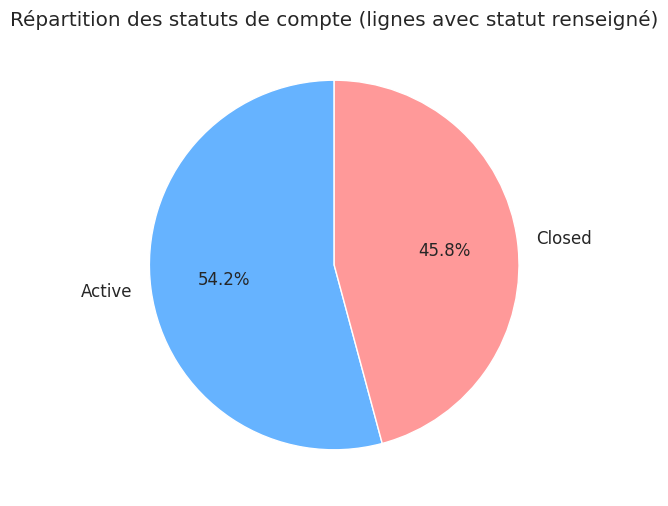

In [14]:
status_counts = df['ACCOUNT_STATUS'].value_counts()
status_pct = df['ACCOUNT_STATUS'].value_counts(normalize=True) * 100

print("Répartition de ACCOUNT_STATUS :")
print(pd.DataFrame({'Count': status_counts, 'Percentage': status_pct.round(2)}))

n_status_missing = df['ACCOUNT_STATUS'].isnull().sum()
print(f"\nLignes sans ACCOUNT_STATUS renseigné : {n_status_missing:,} "
      f"({n_status_missing/len(df)*100:.1f}%) — exclues du calcul ci-dessus, "
      f"à traiter explicitement en ETL plutôt que de les ignorer silencieusement.")

plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Répartition des statuts de compte (lignes avec statut renseigné)')
plt.show()

**Déséquilibre de classes** : la documentation signale un déséquilibre entre comptes
actifs et clos à anticiper dans le modèle ML (pondération des classes, SMOTE, métriques adaptées —
precision/recall/F1/ROC-AUC plutôt que la seule accuracy). La répartition ci-dessus n'est pas
extrêmement déséquilibrée au niveau ligne, mais ce point devra être réévalué une fois la définition
finale du churn arrêtée (ligne vs. client) au moment de préparer le jeu d'entraînement.

## 8. Analyse univariée des variables numériques

### 8.1 Âge des clients (`DATE_OF_BIRTH`)

⚠️ Le profilage des données montre des valeurs de `DATE_OF_BIRTH` clairement erronées (années comme
1190, 1373...). On les identifie et on les **exclut explicitement avant tout calcul d'âge**, plutôt
que de les laisser fausser silencieusement les moyennes et les graphiques en aval — c'est l'erreur
qui s'était glissée dans une version précédente de ce notebook (l'anomalie était détectée puis
oubliée dans les analyses suivantes).

Valeurs de DATE_OF_BIRTH hors plage plausible [1916, 2026] : 262
DATE_OF_BIRTH
1190.00    3
1191.00    2
1193.00    1
1195.00    1
1197.00    1
1198.00    1
1373.00    1
1645.00    1
1657.00    1
1659.00    1
1672.00    1
1692.00    1
1696.00    1
1697.00    3
1798.00    1
1850.00    1
1851.00    1
1874.00    2
1882.00    1
1888.00    1
Name: count, dtype: int64


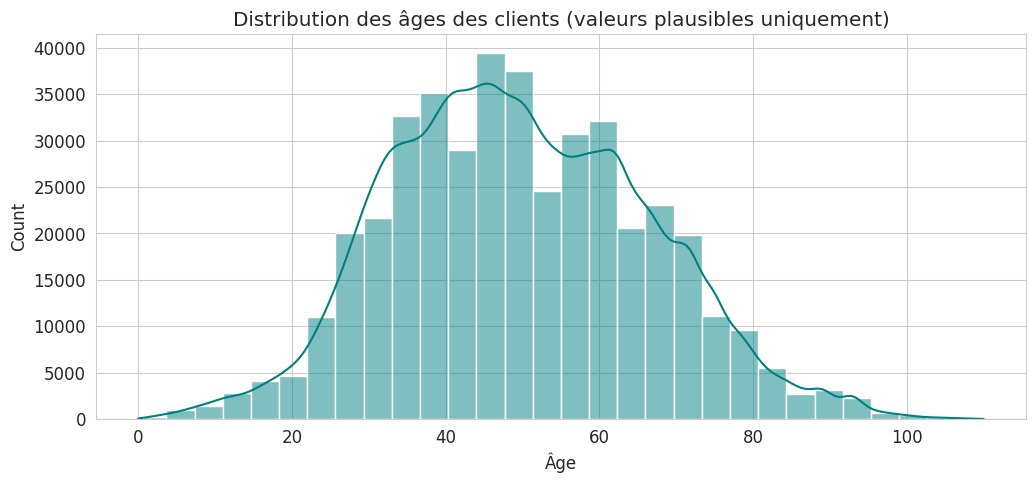


Âge moyen  : 49.7 ans
Âge médian : 49.0 ans
Lignes exclues du calcul d'âge (DOB manquant ou implausible) : 101,577 (19.2%)


In [15]:
# Bornes de plausibilité pour une année de naissance : personne de 0 à 110 ans
MIN_BIRTH_YEAR = REFERENCE_YEAR - 110
MAX_BIRTH_YEAR = REFERENCE_YEAR

invalid_dob = df[
    df['DATE_OF_BIRTH'].notna()
    & ((df['DATE_OF_BIRTH'] < MIN_BIRTH_YEAR) | (df['DATE_OF_BIRTH'] > MAX_BIRTH_YEAR))
]
print(f"Valeurs de DATE_OF_BIRTH hors plage plausible [{MIN_BIRTH_YEAR}, {MAX_BIRTH_YEAR}] : "
      f"{len(invalid_dob):,}")
if len(invalid_dob) > 0:
    print(invalid_dob['DATE_OF_BIRTH'].value_counts().sort_index().head(20))

# AGE calculé uniquement sur les valeurs plausibles : les autres deviennent NaN explicitement
df['AGE'] = np.where(
    df['DATE_OF_BIRTH'].between(MIN_BIRTH_YEAR, MAX_BIRTH_YEAR),
    REFERENCE_YEAR - df['DATE_OF_BIRTH'],
    np.nan,
)

plt.figure(figsize=(12, 5))
sns.histplot(df['AGE'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution des âges des clients (valeurs plausibles uniquement)')
plt.xlabel('Âge')
plt.show()

print(f"\nÂge moyen  : {df['AGE'].mean():.1f} ans")
print(f"Âge médian : {df['AGE'].median():.1f} ans")
print(f"Lignes exclues du calcul d'âge (DOB manquant ou implausible) : "
      f"{df['AGE'].isnull().sum():,} ({df['AGE'].isnull().mean()*100:.1f}%)")

### 8.2 `SCORE_KYC`

Le `SCORE_KYC` classe les clients par niveau de risque de conformité :
- **LR** (Low Risk) : risque faible, clients standards.
- **MR** (Medium Risk) : risque moyen, vigilance accrue.
- **H1 / H2 / H3** (High Risk, croissant) : risque élevé (PEP, zones sensibles, anomalies
  documentaires). `H1` le moins critique, `H3` le plus sévère.

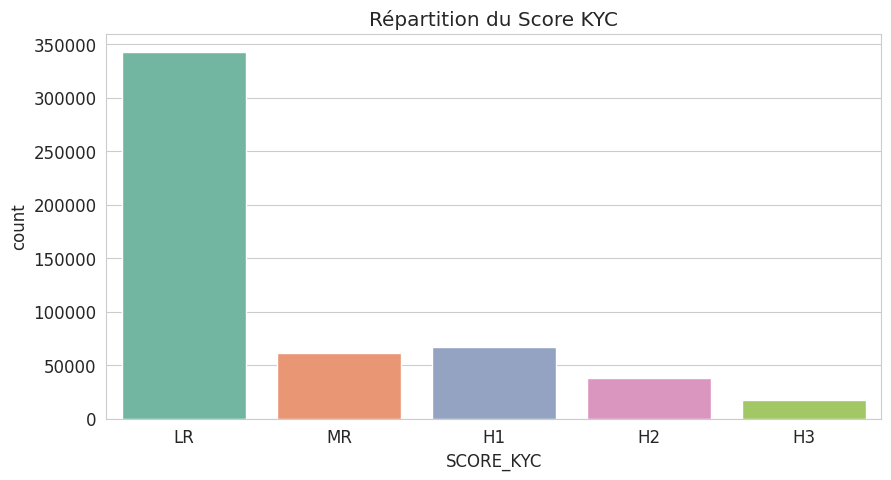

In [16]:
plt.figure(figsize=(10, 5))
kyc_order = [c for c in ['LR', 'MR', 'H1', 'H2', 'H3'] if c in df['SCORE_KYC'].dropna().unique()]
sns.countplot(data=df, x='SCORE_KYC', order=kyc_order, palette='Set2')
plt.title('Répartition du Score KYC')
plt.show()

Répartition en % par SCORE_KYC (ligne) :
ACCOUNT_STATUS  Active  Closed
SCORE_KYC                     
H1               36.80   63.20
H2               35.20   64.80
H3               26.30   73.70
LR               59.70   40.30
MR               60.40   39.60


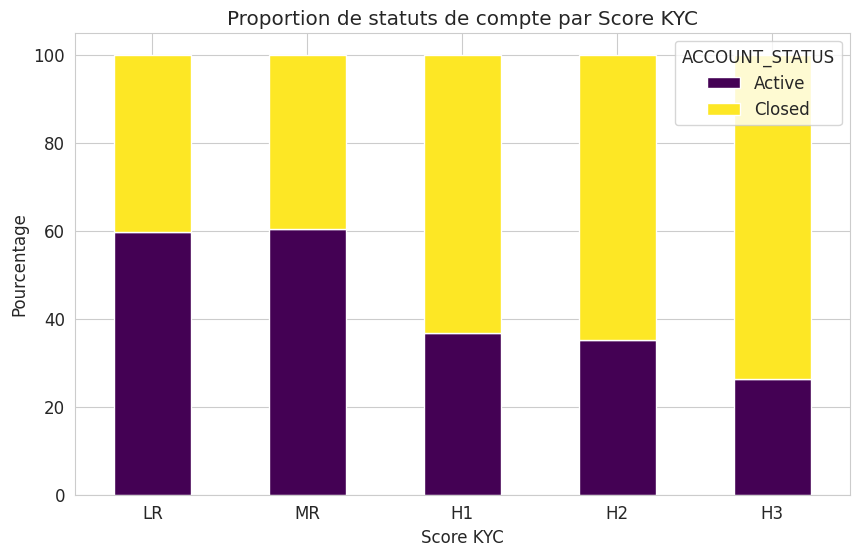

In [17]:
cross_tab_pct = pd.crosstab(df['SCORE_KYC'], df['ACCOUNT_STATUS'], normalize='index') * 100
print("Répartition en % par SCORE_KYC (ligne) :")
print(cross_tab_pct.round(1))

cross_tab_pct.reindex(kyc_order).plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proportion de statuts de compte par Score KYC')
plt.ylabel('Pourcentage')
plt.xlabel('Score KYC')
plt.legend(title='ACCOUNT_STATUS')
plt.xticks(rotation=0)
plt.show()

### 8.3 `SALARY` (salaire déclaré)

On exclut explicitement les valeurs manquantes pour les statistiques de distribution (déjà
analysées séparément en section 5.3), et on traite les outliers par la méthode IQR sans les
supprimer du jeu de données — seulement pour caractériser la distribution.

Statistiques descriptives de SALARY (valeurs renseignées uniquement) :
count     202234.00
mean        5588.48
std       149836.63
min            0.00
1%           400.00
5%           400.00
25%          400.00
50%          612.00
75%         1647.00
95%         5000.00
99%        20000.00
max     25000000.00
Name: SALARY, dtype: float64

Bornes IQR : [-1470.50, 3517.50]
Outliers IQR : 21,738 (10.75%)


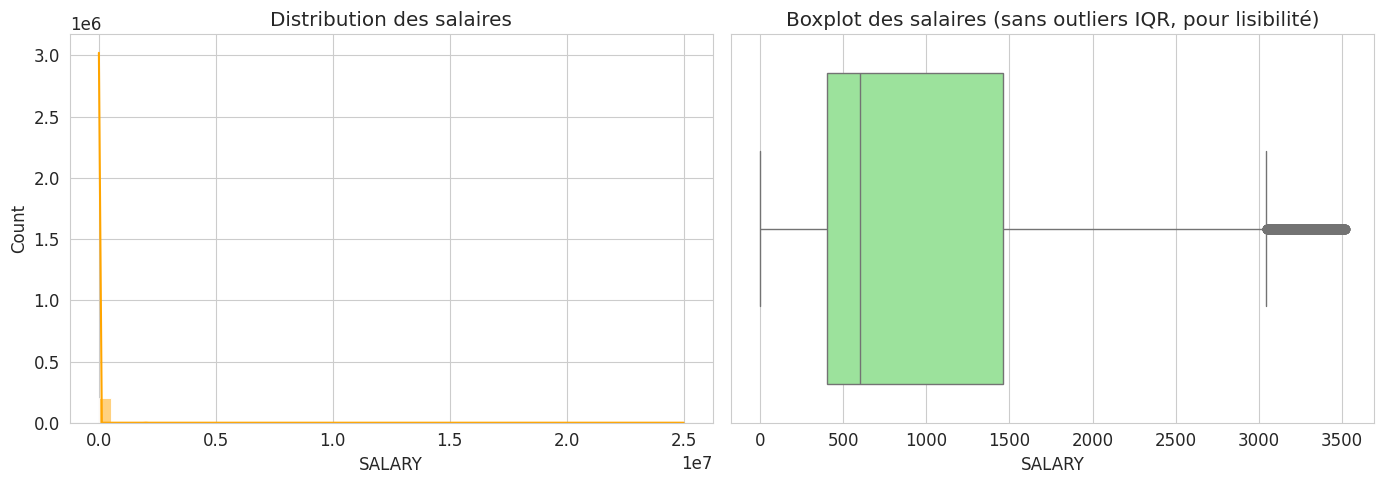

In [18]:
salary = df['SALARY'].dropna()

print("Statistiques descriptives de SALARY (valeurs renseignées uniquement) :")
print(salary.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Q1, Q3 = salary.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = salary[(salary < lower_bound) | (salary > upper_bound)]
print(f"\nBornes IQR : [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers IQR : {len(outliers):,} ({len(outliers)/len(salary)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(salary, bins=50, kde=True, color='orange', ax=axes[0])
axes[0].set_title('Distribution des salaires')
sns.boxplot(x=salary[(salary >= lower_bound) & (salary <= upper_bound)],
            color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot des salaires (sans outliers IQR, pour lisibilité)')
plt.tight_layout()
plt.show()

Test de Mann-Whitney (SALARY, Active vs Closed) : p-value = 0.000000
=> Différence statistiquement significative entre les deux groupes (p < 0.05).


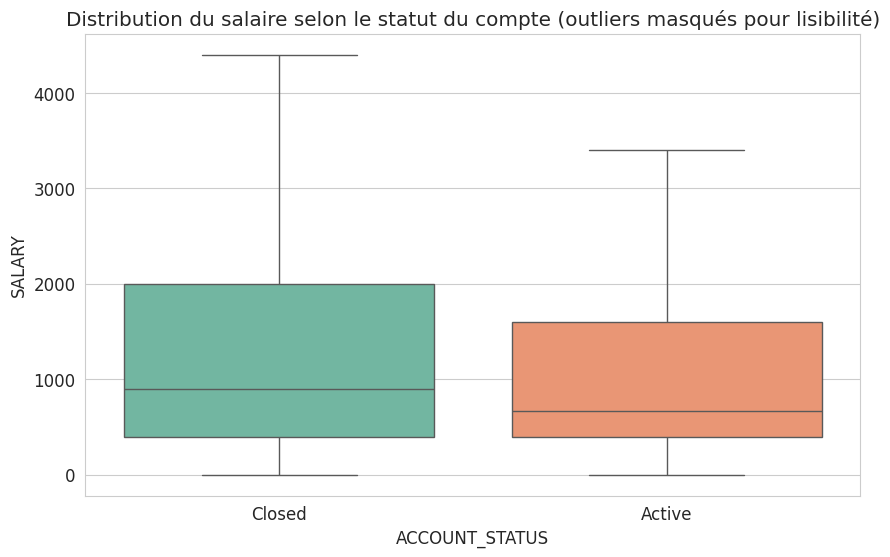

In [19]:
from scipy import stats

active_salary = df.loc[df['ACCOUNT_STATUS'] == 'Active', 'SALARY'].dropna()
closed_salary = df.loc[df['ACCOUNT_STATUS'] == 'Closed', 'SALARY'].dropna()

stat, p_value = stats.mannwhitneyu(active_salary, closed_salary, alternative='two-sided')
print(f"Test de Mann-Whitney (SALARY, Active vs Closed) : p-value = {p_value:.6f}")
if p_value < 0.05:
    print("=> Différence statistiquement significative entre les deux groupes (p < 0.05).")
else:
    print("=> Pas de différence statistiquement significative détectée (p >= 0.05).")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ACCOUNT_STATUS', y='SALARY', palette='Set2', showfliers=False)
plt.title('Distribution du salaire selon le statut du compte (outliers masqués pour lisibilité)')
plt.show()

### 8.4 `ACCT_BALANCE`

Le solde contient à la fois des valeurs très négatives (découverts, crédits en cours) et très
positives. On utilise une échelle symlog pour la visualisation plutôt qu'une échelle log classique,
qui ne supporte pas les valeurs négatives.

Solde moyen  : 4,409.02
Solde médian : 2.09
Min / Max    : -43,823,115.66 / 64,141,930.15


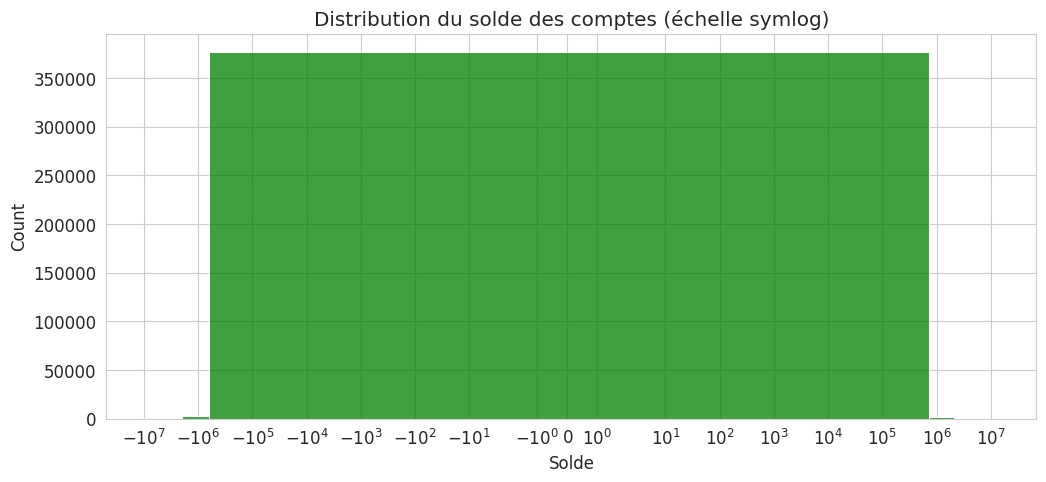

In [20]:
balance = df['ACCT_BALANCE'].dropna()
print(f"Solde moyen  : {balance.mean():,.2f}")
print(f"Solde médian : {balance.median():,.2f}")
print(f"Min / Max    : {balance.min():,.2f} / {balance.max():,.2f}")

plt.figure(figsize=(12, 5))
sns.histplot(balance, bins=80, color='green')
plt.xscale('symlog')
plt.title('Distribution du solde des comptes (échelle symlog)')
plt.xlabel('Solde')
plt.show()

Statistiques descriptives du solde par statut de compte :


,count,mean,std,min,25%,50%,75%,max
ACCOUNT_STATUS,,,,,,,,
Active,262502.00,-383.89,356107.66,-43823115.66,0.00,13.88,1821.44,64141930.15
Closed,121456.00,14767.90,1342785.38,-31601046.03,-13809.36,0.00,7.62,49147697.67


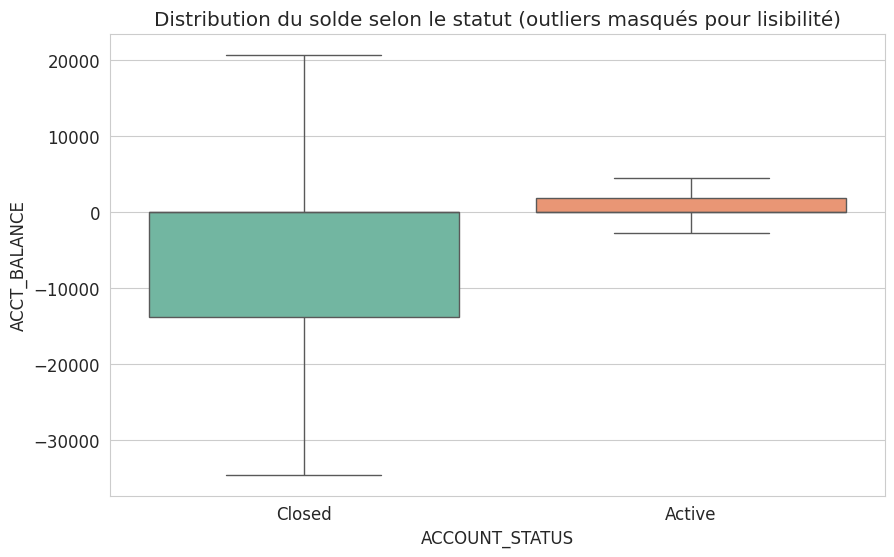

In [21]:
balance_by_status = df.groupby('ACCOUNT_STATUS')['ACCT_BALANCE'].describe()
print("Statistiques descriptives du solde par statut de compte :")
display(balance_by_status.round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ACCOUNT_STATUS', y='ACCT_BALANCE', palette='Set2', showfliers=False)
plt.title('Distribution du solde selon le statut (outliers masqués pour lisibilité)')
plt.show()

## 9. Analyse univariée des variables catégorielles clés

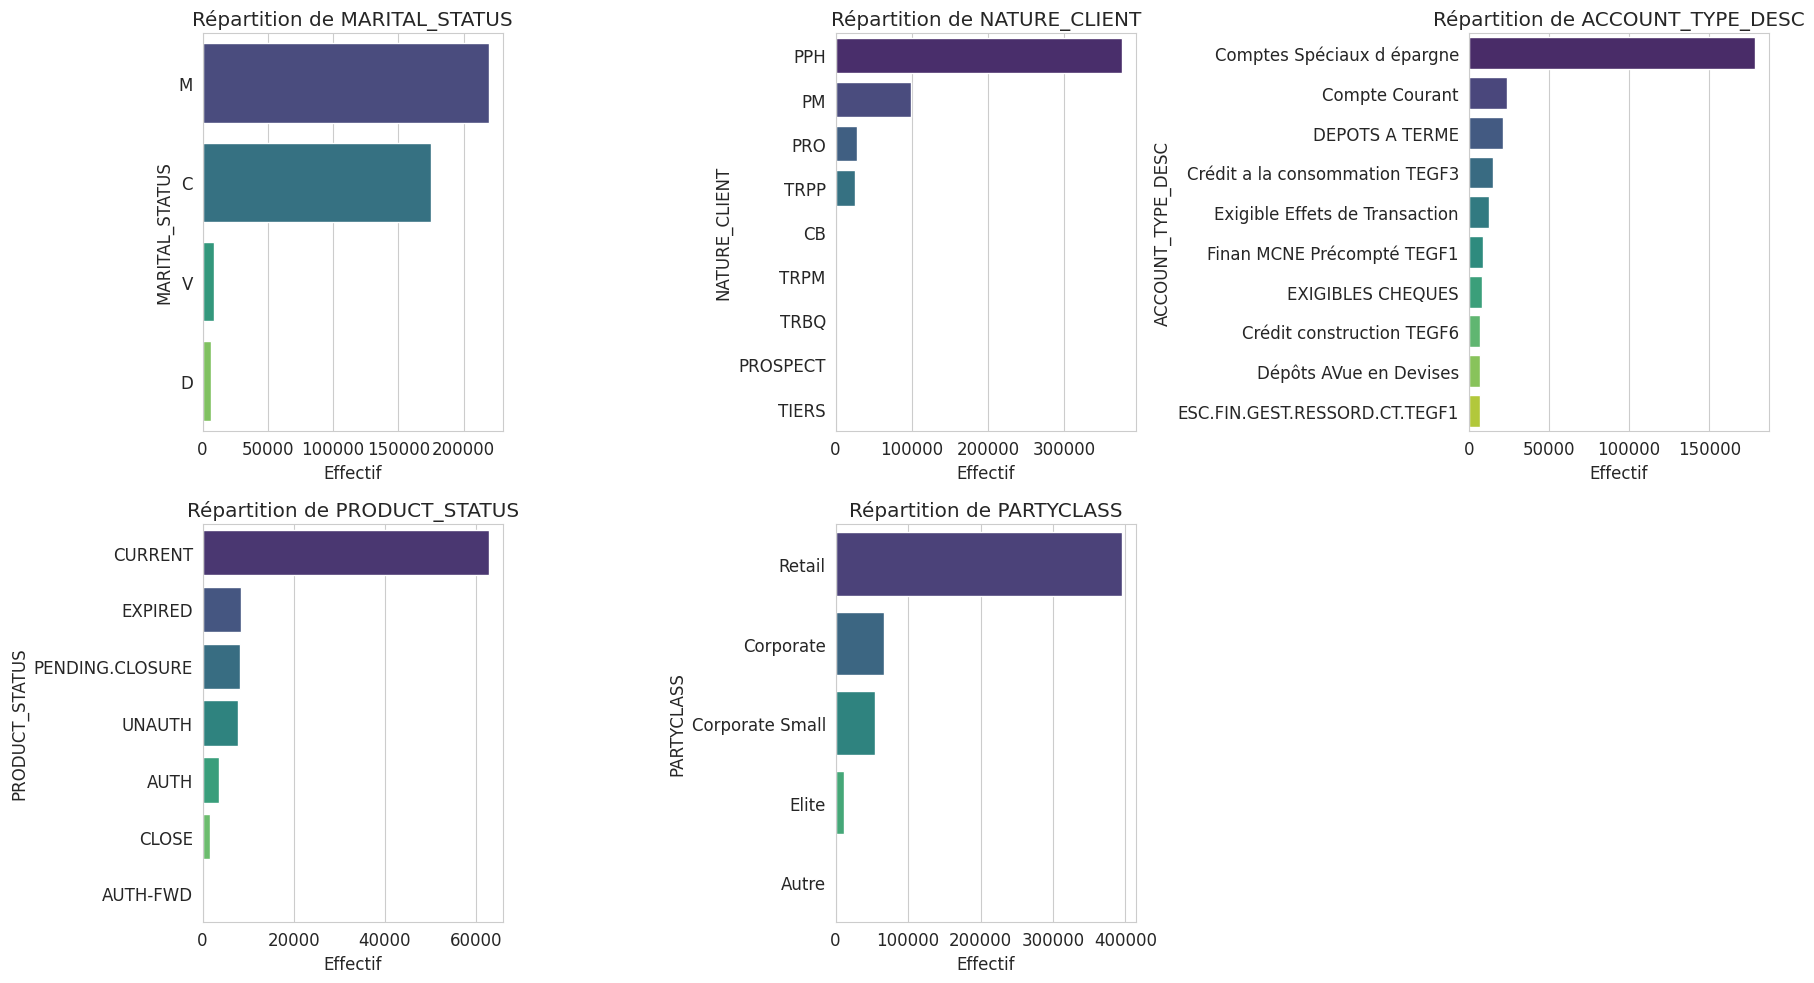

In [22]:
categorical_cols = ['MARITAL_STATUS', 'NATURE_CLIENT', 'ACCOUNT_TYPE_DESC',
                    'PRODUCT_STATUS', 'PARTYCLASS']
categorical_cols = [c for c in categorical_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().head(10)
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Répartition de {col}')
    axes[i].set_xlabel('Effectif')

for ax in axes[len(categorical_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### `INDUSTRY` : note de lecture

D'après le profilage, `INDUSTRY` vaut **9000 pour la grande majorité des lignes** (Q1 = Q3 = 9000).
La section 9.5 ci-dessous confirme, via `dim_INDUSTRY.xlsx`, que ce code signifie bien "non
renseigné / particulier" — ce n'était qu'une hypothèse statistique avant cette vérification. Tant
qu'on raisonne sur les codes bruts, toute analyse de churn par secteur d'activité doit être lue
**en excluant ou en isolant le code 9000**, sous peine de noyer le signal des vrais secteurs
minoritaires.

In [23]:
industry_counts = df['INDUSTRY'].value_counts()
top_industries = industry_counts.head(15)

print("Top 15 codes INDUSTRY (avant exclusion de 9000) :")
print(top_industries)

print(f"\nPart du code 9000 : {(df['INDUSTRY'] == 9000).mean() * 100:.1f}%")

Top 15 codes INDUSTRY (avant exclusion de 9000) :
INDUSTRY
9000    327362
9998     49296
9900     25792
1041     10425
610       8173
8710      3134
5520      2479
4638      2402
4752      2253
4299      2191
4531      1718
4669      1717
6910      1603
1729      1493
111       1488
Name: count, dtype: int64

Part du code 9000 : 61.9%


### 9.5 Décodage des codes via les tables de dimensions (`dim_*.xlsx`)

Les 8 fichiers `dim_*.xlsx` fournis par l'encadrant donnent le libellé métier réel associé aux
codes du fichier principal. Jusqu'ici, ce notebook ne faisait que des hypothèses statistiques sur
leur signification (ex. "9000 ressemble à une catégorie fourre-tout"). On vérifie maintenant ces
hypothèses directement, plutôt que de les laisser comme suppositions non confirmées.

In [24]:
dim_industry = pd.read_excel("../../data/dim_INDUSTRY.xlsx")
dim_industry = dim_industry.rename(
    columns={'INDUSTRY_CODE': 'INDUSTRY', 'INDUSTRY DESCRIPTION': 'INDUSTRY_LABEL'}
)
dim_industry['INDUSTRY'] = dim_industry['INDUSTRY'].astype(str)

# df['INDUSTRY'] est numérique dans le fichier source (contrairement au module ETL,
# qui le caste explicitement en texte) : on aligne les types ici, juste pour cette
# jointure, sans modifier df lui-même (cf. note de méthode section 4 sur le fait de
# ne pas ajouter de colonnes jetables à df).
industry_key = df['INDUSTRY'].astype('Int64').astype(str)

label_9000 = dim_industry.loc[dim_industry['INDUSTRY'] == '9000', 'INDUSTRY_LABEL']
label_9998 = dim_industry.loc[dim_industry['INDUSTRY'] == '9998', 'INDUSTRY_LABEL']

print(f"Code 9000 -> {label_9000.iloc[0] if len(label_9000) else 'INTROUVABLE dans dim_INDUSTRY'}")
print(f"Code 9998 -> "
      f"{label_9998.iloc[0] if len(label_9998) else 'INTROUVABLE dans dim_INDUSTRY (gap réel du référentiel)'}")

Code 9000 -> Other
Code 9998 -> INTROUVABLE dans dim_INDUSTRY (gap réel du référentiel)


**Confirmation** : le code 9000 correspond bien au libellé `"Other"` dans le référentiel
officiel — l'hypothèse précédente était correcte, et est maintenant vérifiée plutôt que supposée.
Le code 9998, en revanche, **n'existe pas du tout** dans `dim_INDUSTRY.xlsx` : ce n'est pas une
hypothèse à discuter, c'est un vrai trou du référentiel fourni, à signaler dans le rapport plutôt
qu'à deviner.

In [25]:
df_with_industry_label = df.copy()
df_with_industry_label['INDUSTRY'] = industry_key  # version texte, alignée avec dim_industry
df_with_industry_label = df_with_industry_label.merge(
    dim_industry[['INDUSTRY', 'INDUSTRY_LABEL']], on='INDUSTRY', how='left'
)

n_unmatched = (
    df_with_industry_label['INDUSTRY_LABEL'].isna()
    & df_with_industry_label['INDUSTRY'].notna()
).sum()
print(f"Lignes avec un code INDUSTRY non trouvé dans le référentiel : {n_unmatched:,} "
      f"({n_unmatched/len(df)*100:.1f}%)")

print("\nTop 10 des secteurs réels les plus fréquents (hors code 9000) :")
print(
    df_with_industry_label[df_with_industry_label['INDUSTRY'] != '9000']['INDUSTRY_LABEL']
        .value_counts()
        .head(10)
)

Lignes avec un code INDUSTRY non trouvé dans le référentiel : 49,310 (9.3%)

Top 10 des secteurs réels les plus fréquents (hors code 9000) :
INDUSTRY_LABEL
activites des organisations et organismes extraterritoriaux               25792
fabrication huiles olives                                                 10425
extraction de petrole brut                                                 8173
hebergement medicalise                                                     3134
hebergement touristique et autre hebergement de courte duree               2479
commerce de gros specialise autres produits alimentaires                   2402
commerce de detail de quincaillerie, peintures et verres en magasin sp     2253
construction autres ouvrages de genie civil n.c.a.                         2191
commerce de gros equipements automobiles                                   1718
commerce de gros autres machines et equipements                            1717
Name: count, dtype: int64


### 9.6 Décodage des motifs de clôture (`dim_Closure_reason.xlsx`)

Les motifs de clôture (`CLOSURE_REASON`) sous forme `BANK.REASON.N` étaient jusqu'ici complètement
opaques. `dim_Closure_reason.xlsx` donne le libellé réel associé à chaque numéro — ce qui permet
enfin de comprendre *pourquoi* le motif `BANK.REASON.13` domine à lui seul (24% des clôtures).

⚠️ Ce fichier de dimension contient encore, dans sa colonne d'identifiant brut, le nom réel de
l'institution source sous forme d'acronyme. On l'utilise uniquement via son numéro de motif pour
la jointure, et on ne reproduit jamais ce nom dans les sorties de ce notebook, conformément à la
règle d'anonymat de la documentation.

In [26]:
import re

dim_closure_raw = pd.read_excel("../../data/dim_Closure_reason.xlsx")

# Extraction du numéro de motif uniquement (pas du préfixe contenant le nom de la banque)
dim_closure_raw['reason_number'] = dim_closure_raw['RECID'].str.extract(r'REASON\.(\d+)$')
dim_closure_raw['closure_code'] = dim_closure_raw['reason_number'].apply(
    lambda n: f"BANK.REASON.{n}" if pd.notna(n) else None
)
# Le nom réel de la banque est retiré du libellé avant tout usage, par sécurité,
# même si DESCRIPTION ne devrait contenir que du texte métier.
dim_closure_raw['DESCRIPTION'] = (
    dim_closure_raw['DESCRIPTION'].astype(str).str.replace(r'\bATB\b', 'BANK', regex=True)
)

closure_lookup = dim_closure_raw.dropna(subset=['closure_code'])[['closure_code', 'DESCRIPTION']]

closure_counts = (
    df.dropna(subset=['CLOSURE_REASON'])['CLOSURE_REASON']
      .value_counts()
      .rename_axis('closure_code')
      .reset_index(name='count')
      .merge(closure_lookup, on='closure_code', how='left')
)
print("Motifs de clôture décodés, triés par fréquence :")
print(closure_counts.head(10).to_string(index=False))

Motifs de clôture décodés, triés par fréquence :
  closure_code  count                                                    DESCRIPTION
BANK.REASON.13 127173                                                          Autre
 BANK.REASON.9  11939                                           Cessation d activite
 BANK.REASON.1   1972                               Changement d adresse de domicile
BANK.REASON.12   1032                                                   Client décdé
BANK.REASON.10    478   Ouverture d un nouveau compte aupres d une autre agence BANK
 BANK.REASON.6    273                                       Refus d octroi de credit
 BANK.REASON.2    257                                             Tarification chere
 BANK.REASON.3    221                                         Changement d employeur
 BANK.REASON.5    141 Recherche service ou produit hors BANK/Convention autre banque
 BANK.REASON.8     23                               Non-traitement d une reclamation


**Lecture** : le motif `BANK.REASON.13` correspond simplement à `"Autre"` (Other) — un motif
fourre-tout, pas une cause identifiable. Sa fréquence élevée ne révèle donc pas une cause de churn
exploitable en l'état ; elle révèle plutôt que le système de catégorisation des motifs de clôture
manque de granularité pour près d'un quart des fermetures de compte. C'est une observation utile
pour la section "limites des données" du rapport.

## 10. Relation entre le statut du compte (churn) et les variables

Pour chaque variable catégorielle, on calcule le **taux de churn par catégorie** (% de lignes
`Closed` au sein de chaque groupe), et on l'accompagne systématiquement de **l'effectif du groupe**
— un taux de churn de 100% sur 3 lignes n'a pas le même poids qu'un taux de 60% sur 50 000 lignes,
et l'afficher sans effectif invite à une mauvaise lecture.

In [27]:
def churn_rate_by_group(frame, group_col, min_count=30):
    """Calcule le taux de churn (% Closed) et l'effectif par groupe.
    Les groupes avec moins de `min_count` lignes sont gardés mais signalés,
    car leur taux de churn est statistiquement peu fiable.
    """
    g = frame.dropna(subset=[group_col, 'ACCOUNT_STATUS']).groupby(group_col)
    result = g['ACCOUNT_STATUS'].apply(lambda x: (x == 'Closed').mean() * 100)
    counts = g.size()
    out = pd.DataFrame({'churn_rate_pct': result, 'count': counts})
    out['low_confidence'] = out['count'] < min_count
    return out.sort_values('churn_rate_pct', ascending=False)


def plot_churn_rate(churn_df, title, top_n=20):
    plot_df = churn_df.sort_values('churn_rate_pct').tail(top_n)
    colors = ['lightgray' if low else 'lightcoral' for low in plot_df['low_confidence']]
    plt.figure(figsize=(12, max(4, 0.35 * len(plot_df))))
    plt.barh(plot_df.index.astype(str), plot_df['churn_rate_pct'], color=colors)
    plt.xlabel('Taux de churn (%)')
    plt.title(f"{title}\n(gris = effectif < seuil de confiance)")
    plt.tight_layout()
    plt.show()

### 10.1 Churn par statut marital

,churn_rate_pct,count,low_confidence
MARITAL_STATUS,,,
D,47.39,6638,False
M,42.02,204266,False
C,38.61,167355,False
V,32.47,8857,False


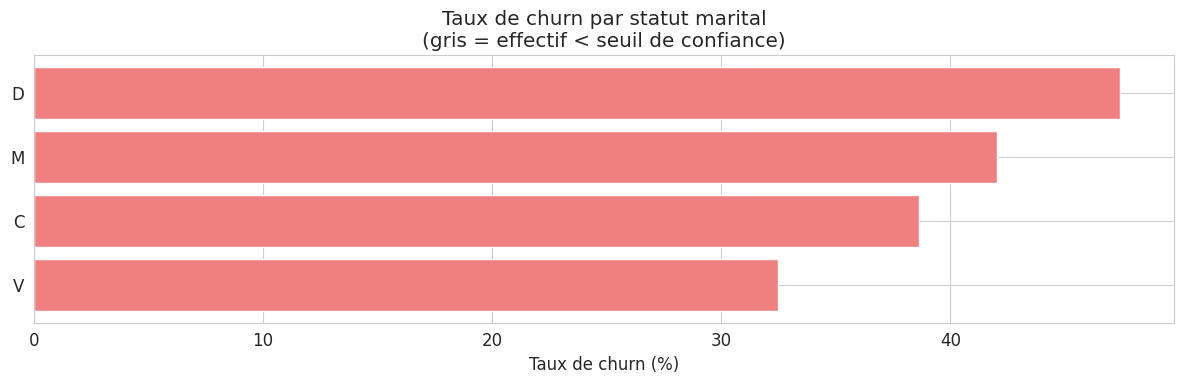

In [28]:
churn_marital = churn_rate_by_group(df, 'MARITAL_STATUS')
display(churn_marital)
plot_churn_rate(churn_marital, 'Taux de churn par statut marital')

### 10.2 Churn par `NATURE_CLIENT`

,churn_rate_pct,count,low_confidence
NATURE_CLIENT,,,
TIERS,100.00,1,True
TRPP,75.00,4,True
PM,67.48,96649,False
PRO,42.34,27381,False
PPH,40.29,360198,False
CB,12.03,133,False


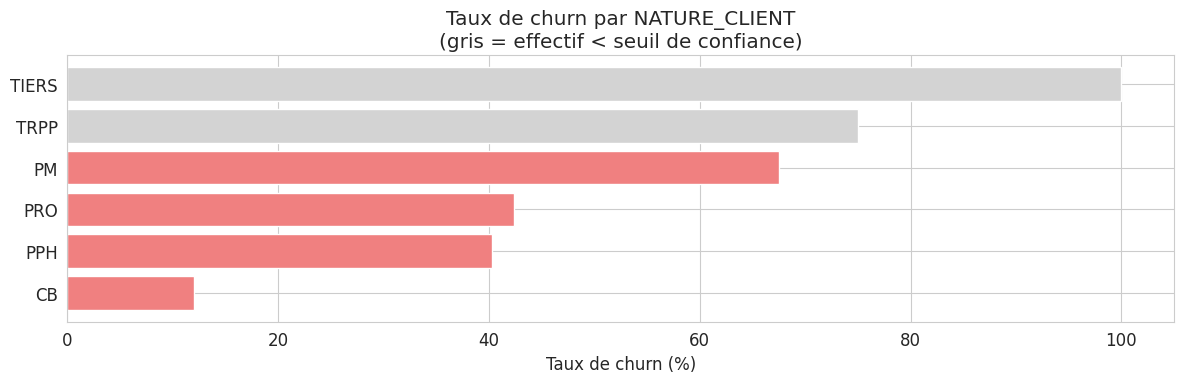

In [29]:
churn_nature = churn_rate_by_group(df, 'NATURE_CLIENT')
display(churn_nature)
plot_churn_rate(churn_nature, 'Taux de churn par NATURE_CLIENT')

### 10.3 Churn par secteur d'activité réel (hors code 9000, libellés `dim_INDUSTRY`)

On réutilise le décodage de la section 9.5 plutôt que d'afficher des codes numériques bruts —
un libellé comme "construction aéronautique et spatiale" est directement interprétable, un code
`2530` ne l'est pas.

Lignes avec un code INDUSTRY autre que 9000 : 201,521 (38.1% du total)


,churn_rate_pct,count,low_confidence
INDUSTRY_LABEL,,,
activites des agences de travail temporaire,100.00,3,True
autres activites hebergement social,100.00,3,True
"location-bail de propriete intellectuelle et de produits similaires, e",100.00,1,True
fabrication aliments homogeneises et dietetiques,100.00,1,True
commerce de combustibles gazeux par conduites,100.00,1,True
fabrication ouvrages en fibre ciment,100.00,1,True
"chasse, piegeage et services annexes",100.00,2,True
extraction de tourbe,100.00,1,True
fabrication de fibres de verre,100.00,2,True


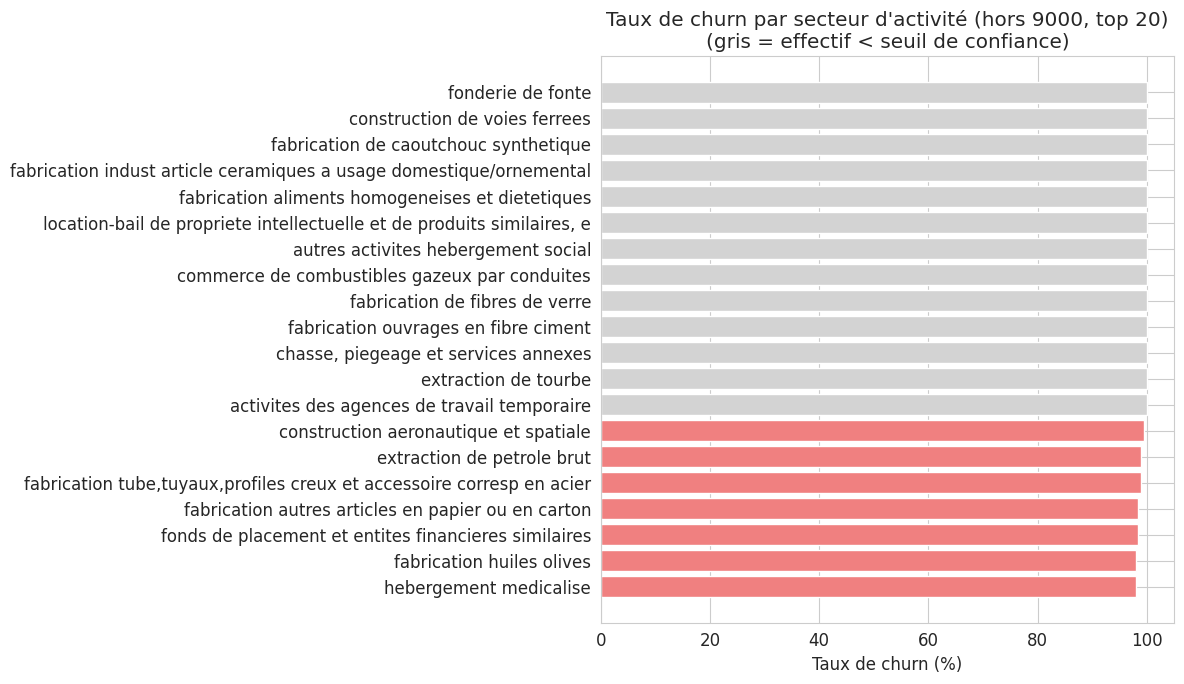

In [30]:
df_industry_known = df_with_industry_label[df_with_industry_label['INDUSTRY'] != '9000']
churn_industry = churn_rate_by_group(df_industry_known, 'INDUSTRY_LABEL')

print(f"Lignes avec un code INDUSTRY autre que 9000 : {len(df_industry_known):,} "
      f"({len(df_industry_known)/len(df)*100:.1f}% du total)")
display(churn_industry.head(20))
plot_churn_rate(churn_industry.head(20), "Taux de churn par secteur d'activité (hors 9000, top 20)")

### 10.4 Âge selon le statut

Calculé uniquement sur les valeurs d'âge plausibles (section 8.1) — c'est le point qui avait
introduit un biais (âges de plusieurs centaines d'années) dans une version précédente de cette
analyse.

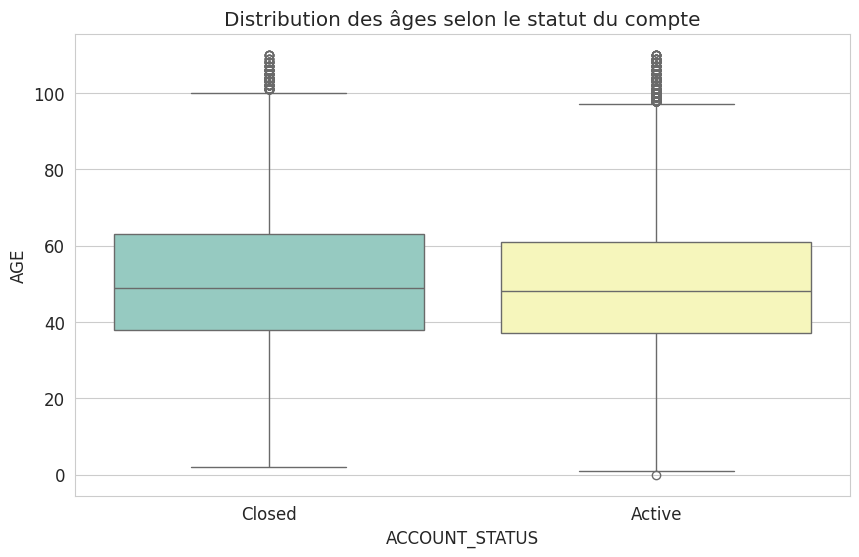

Statistiques descriptives de l'âge par statut de compte :


,count,mean,std,min,25%,50%,75%,max
ACCOUNT_STATUS,,,,,,,,
Active,229681.00,48.50,17.00,0.00,37.00,48.00,61.00,110.00
Closed,156504.00,50.80,16.60,2.00,38.00,49.00,63.00,110.00


In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ACCOUNT_STATUS', y='AGE', palette='Set3')
plt.title("Distribution des âges selon le statut du compte")
plt.show()

print("Statistiques descriptives de l'âge par statut de compte :")
display(df.groupby('ACCOUNT_STATUS')['AGE'].describe().round(1))

## 11. Analyse temporelle

On réutilise ici la conversion de dates déjà calculée en section 4 (`parsed_dates`), sans
modifier `df` — on construit une petite série temporaire à la volée pour ce graphique précis.

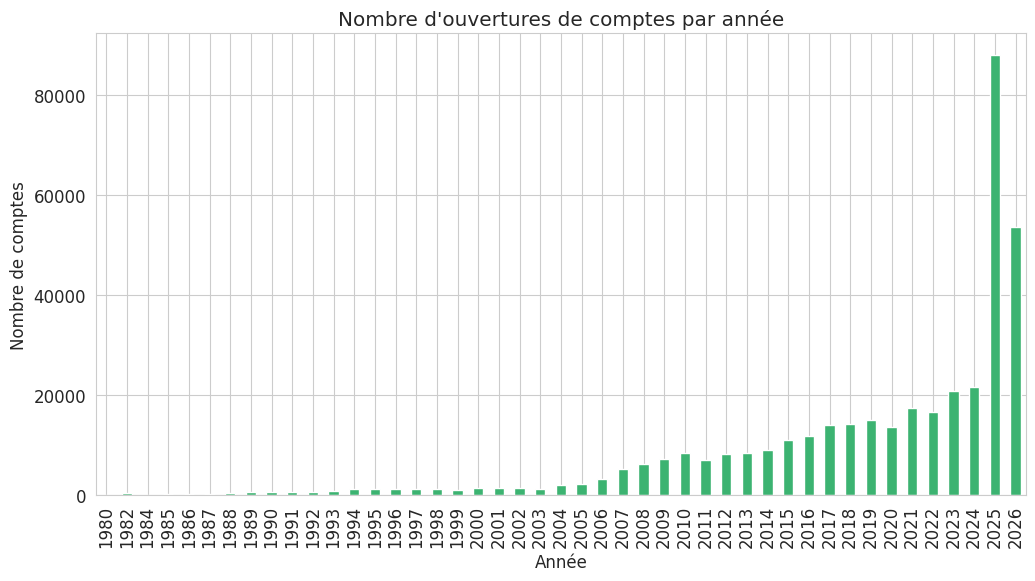

In [32]:
acct_opening_dt = parsed_dates['ACCT_OPENING_DATE']

openings_by_year = (
    acct_opening_dt.dropna()
      .dt.year
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(12, 6))
openings_by_year.plot(kind='bar', color='mediumseagreen')
plt.title("Nombre d'ouvertures de comptes par année")
plt.xlabel('Année')
plt.ylabel('Nombre de comptes')
plt.show()

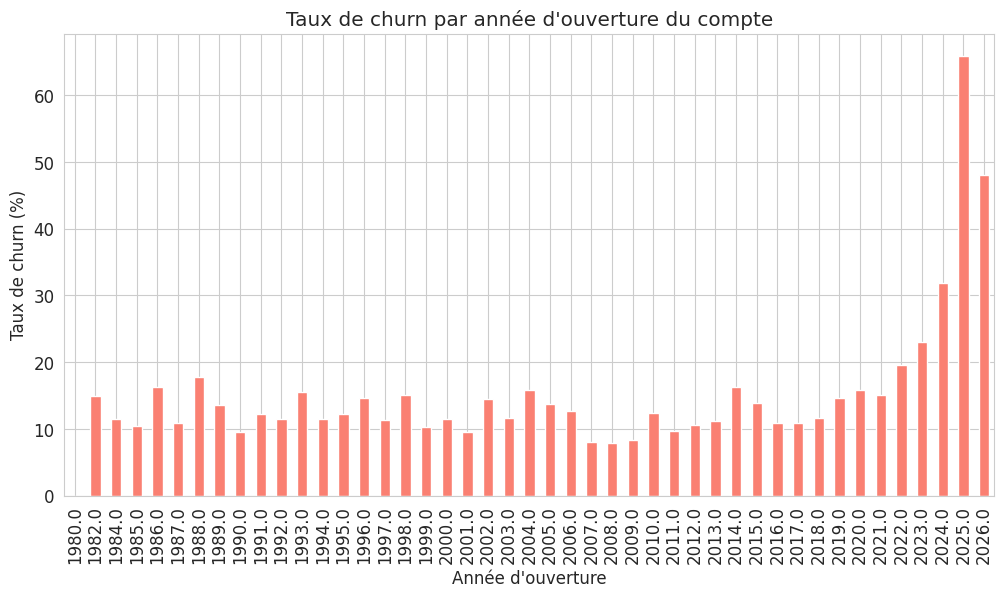

In [33]:
# On aligne la date convertie avec ACCOUNT_STATUS via l'index commun (même `df`,
# donc même index), sans jamais ajouter de colonne à `df`.
temporal_df = pd.DataFrame({
    'OPENING_YEAR': acct_opening_dt.dt.year,
    'ACCOUNT_STATUS': df['ACCOUNT_STATUS'],
}).dropna()

churn_by_open_year = (
    temporal_df.groupby('OPENING_YEAR')['ACCOUNT_STATUS']
      .apply(lambda x: (x == 'Closed').mean() * 100)
)

plt.figure(figsize=(12, 6))
churn_by_open_year.plot(kind='bar', color='salmon')
plt.title("Taux de churn par année d'ouverture du compte")
plt.xlabel("Année d'ouverture")
plt.ylabel('Taux de churn (%)')
plt.show()

**Lecture attendue / piège classique** : les comptes ouverts très récemment auront
mécaniquement un taux de churn apparent faible (ils n'ont pas encore eu le temps de se fermer),
indépendamment de tout effet réel. Ne pas conclure que "les nouveaux comptes sont plus fidèles" sur
cette seule base — c'est un biais de troncature temporelle à signaler explicitement dans le rapport
plutôt qu'à ignorer.

## 12. Synthèse et recommandations pour l'étape ETL

Cette section résume, **chiffres réels du fichier `data_churn.txt` à l'appui** (528 883 lignes),
les constats de ce notebook et propose un traitement concret pour chaque problème — à reprendre
dans le README du dossier `01_etl/` ou en issues GitHub.

### 12.1 Récapitulatif des constats

| # | Constat | Ampleur mesurée | Action recommandée en ETL |
|---|---|---|---|
| 1 | Une ligne = (client, compte produit), pas un client | 363 569 clients pour 528 883 lignes (1,45 ligne/client en moyenne, mais 87% des clients n'ont qu'une ligne — quelques comptes techniques en concentrent beaucoup) | Si une définition de churn *client* est retenue en plus de la définition *ligne* de la documentation, construire une agrégation niveau client séparée, documentée et justifiée |
| 2 | Dates `YYYYMMDD` | 0 valeur malformée détectée sur `CUST_OPENING_DATE`, `LAST_REVIEW_DATE`, `NEXT__REVIEW_DATE`, `ACCT_OPENING_DATE`, `ACCT_CLOSE_DATE` | Conversion `to_datetime(format='%Y%m%d')` directement applicable sans gestion d'erreurs particulière pour ces 5 colonnes |
| 3 | `STARTDATE` / `MATURITYDATE` au format incohérent | Mélange de formats à 7 et 8 chiffres, valeurs négatives observées (non quantifié dans ce notebook — volontairement laissé non converti) | Clarifier l'encodage avec l'équipe/encadrant avant toute conversion ; ne pas deviner le format |
| 4 | Nullité structurelle des colonnes produit | 27,4% des lignes n'ont AUCUNE des 4 colonnes produit renseignée (compte non lié à un produit) ; 60,5% les ont toutes ; seulement 12,1% sont dans un cas mixte | Traiter comme une absence de produit, pas comme une donnée manquante à imputer ; la part "mixte" residuelle (12,1%) mérite une investigation séparée |
| 5 | `SALARY` manquant, et corrélé au churn | 61,8% manquant globalement ; mais 66,1% chez les comptes `Closed` contre 55,4% chez les `Active` — écart de 10,7 points | Conserver un indicateur `SALARY_MISSING` comme feature ML à part entière, pas seulement comme note de qualité de données |
| 6 | `DATE_OF_BIRTH` implausible | 262 valeurs hors plage [1916, 2026] sur 427 568 renseignées (0,06%) — marginal en volume mais peut fausser des moyennes si non filtré | Filtrer sur une plage [année courante − 110, année courante] avant tout usage, comme fait en section 8.1 |
| 7 | `INDUSTRY` = 9000 dominant | 61,9% des lignes (327 362) ; le code 9000 écrase largement les vrais secteurs (1041, 610, 8710...) qui ne représentent que 38,1% à eux tous | Confirmer via `dim_INDUSTRY.xlsx` que 9000 = "non renseigné/particulier" ; exclure ou isoler ce code de toute analyse par secteur |
| 8 | Doublons sur (CUSTOMER_NO, ACCOUNT_NO) | 89 690 lignes concernées, regroupées en 16 836 groupes distincts ; 37 068 doublons stricts (toutes colonnes identiques, 7,0%) | Le doublon strict (toutes colonnes identiques) est un cas plus simple à traiter qu'un groupe avec des colonnes différentes (cf. section 6) — vérifier si ce sont des extractions à dates différentes avant de dédupliquer aveuglément |
| 9 | `ACCOUNT_STATUS` manquant | 44 440 lignes (8,4%) sans statut renseigné, exclues du calcul de répartition Active/Closed | Décider explicitement en ETL : exclure ces lignes du jeu de modélisation, ou les traiter comme un 3ème statut "inconnu" — ne pas les laisser disparaître silencieusement d'une étape à l'autre |
| 10 | Biais de troncature temporelle | Non quantifié ici mais visible en section 11 : les comptes ouverts récemment ont mécaniquement moins eu le temps de fermer | À mentionner explicitement dans le rapport comme limite de l'analyse "churn par année d'ouverture" |

### 12.2 Recommandations de traitement des valeurs manquantes par colonne (pour l'ETL)

| Colonne(s) | Stratégie recommandée | Justification |
|---|---|---|
| `PRODUCT_GROUP`, `PRODUCT_LINE`, `PRODUCT`, `ACCOUNTNATURE`, `ACCOUNT_CATEGORY`, `ACCOUNT_TYPE_DESC`, `CURRENCY`, `ACCT_BALANCE` (toutes ~27,4%) | Remplacer par une catégorie explicite `"Pas de produit"` / conserver `NaN` avec un indicateur booléen associé, **ne pas imputer une valeur arbitraire** | Nullité structurelle confirmée (section 5.2) : la ligne ne correspond simplement pas à un produit |
| `SALARY` (61,8%) | Conserver `NaN` + ajouter `SALARY_MISSING` comme feature | La nullité elle-même est corrélée au churn (constat #5) — l'imputer ferait perdre ce signal |
| `CLOSURE_REASON` (72,9%) | `NaN` attendu pour tout compte `Active` — vérifier la cohérence (`CLOSURE_REASON` rempli implique `ACCOUNT_STATUS == 'Closed'`) plutôt que d'imputer | Nullité structurelle liée au statut, pas une vraie donnée manquante |
| `STARTDATE`, `MATURITYDATE`, `FIXEDRATE` (82–85%) | Ne pas traiter avant clarification du format (constat #3) | Imputer ou convertir un format mal compris produirait des dates/taux faux silencieusement |
| `DATE_OF_BIRTH` (19,2%) + 0,06% implausibles | `NaN` conservé, pas d'imputation par une moyenne/médiane (fausserait l'âge) ; filtrer les valeurs implausibles avant tout calcul d'âge | L'âge est une variable démographique sensible pour le ML — mieux vaut un `NaN` honnête qu'une valeur inventée |
| `MARITAL_STATUS` (22,4%) | Catégorie explicite `"Non renseigné"` plutôt que suppression de lignes | Conserver le volume de données ; la non-déclaration peut elle-même être informative |
| `ACCOUNT_STATUS` (8,4%) | Décision explicite d'équipe : exclure ces lignes du jeu de modélisation (cible inconnue = inutilisable en supervisé), mais les garder pour les analyses descriptives qui ne dépendent pas du statut | Une valeur cible manquante ne peut pas être imputée sans biaiser le modèle |

> **Point de vigilance transverse** : ce notebook n'a ajouté que deux colonnes dérivées à `df`
> (`AGE`, `SALARY_MISSING`), volontairement, car elles sont réutilisées dans plusieurs analyses.
> Tout autre calcul intermédiaire (comme la conversion de dates en section 4) a été conservé dans
> des variables Python séparées plutôt que d'être ajouté à `df`, justement pour que les comptages
> de cette section restent fidèles aux 34 colonnes du fichier source — voir la note de méthode en
> section 4 pour le détail.